### Бибилиотеки

In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose



### Работа с данными загрузка и очистка


In [253]:
#"Загрузка данных"
dt = pd.read_csv("PP12_ISP22_analytics.csv")
print(
    "\n",
    "   Наши даные",
    "\n",
    dt.head(400),"\n",
    "_"*50
    )
print(
    "   Проверка на пропуски в данных\n",
    "\n",
    dt.isnull().sum().reset_index(),"\n",
    "_"*50
    )



    Наши даные 
            date  revenue  expenses  customers  orders  profit
0    2023-01-01   124131    115694        279     232    8437
1    2023-01-02    75963     45032        359     235   30931
2    2023-01-03   151757     57846        408     245   93911
3    2023-01-04   149259     79474        454     150   69785
4    2023-01-05    89063     64936        251      95   24127
..          ...      ...       ...        ...     ...     ...
395  2024-01-31    89922    133175        183     203  -43253
396  2024-02-01    92913     86549        260      76    6364
397  2024-02-02   147033    134914        109     241   12119
398  2024-02-03   154792     43705        477     182  111087
399  2024-02-04   169863     87364        426      38   82499

[400 rows x 6 columns] 
 __________________________________________________
   Проверка на пропуски в данных
 
        index  0
0       date  0
1    revenue  0
2   expenses  0
3  customers  0
4     orders  0
5     profit  0 
 ___________

In [254]:
#"На первый взглияд пропуски отсутствуют"
print(
    "Проверка на пропуски повторно также просмотр типов данных\n",
    "_"*50
    )

dt.info()

#"Просто удалим ничего да это делать бессмысленно но пусть будет по условию надо удалить пропуски вот удаляем ничего)"
dt = dt.dropna()
dt = dt.dropna(axis=1)

print(
    "_"*50,"\n",
    "Количество наших данных/не поменяется удаставеряемся" 
    )
dt.shape

Проверка на пропуски повторно также просмотр типов данных
 __________________________________________________
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   date       400 non-null    str  
 1   revenue    400 non-null    int64
 2   expenses   400 non-null    int64
 3   customers  400 non-null    int64
 4   orders     400 non-null    int64
 5   profit     400 non-null    int64
dtypes: int64(5), str(1)
memory usage: 18.9 KB
__________________________________________________ 
 Количество наших данных/не поменяется удаставеряемся


(400, 6)

In [255]:
#"Пора по работать с выбросами и дубликатами данные не содержат пропусков и 0 значений"
dt = dt.drop_duplicates()
dt.shape
#"дубликатов нету ) надо попосмотреть или есть выбросы"\

(400, 6)

'revenue'
 Q1 85504.25 
 Q3 164021.5 
 IQR 78517.25 
 Нижн возм гран -32271.625 
 Верхн возм гран 281797.375 

__________________________________________________ 
  Самый маленькие)
            date  revenue  expenses  customers  orders  profit
303  2023-10-31    50207    139246        485     297  -89039
75   2023-03-17    50281    120689        448     270  -70408
168  2023-06-18    51177    114439        299      60  -63262
101  2023-04-12    51969     34056        475      81   17913
204  2023-07-24    53654    116718        420     258  -63064 
 __________________________________________________ 
 Самые большие)
            date  revenue  expenses  customers  orders  profit
380  2024-01-16   197992    137322         74      32   60670
129  2023-05-10   198159    110900        223     198   87259
261  2023-09-19   198697    118989        292      75   79708
392  2024-01-28   199340    123555        314     188   75785
70   2023-03-12   199381     79353        247     220  120028 
 

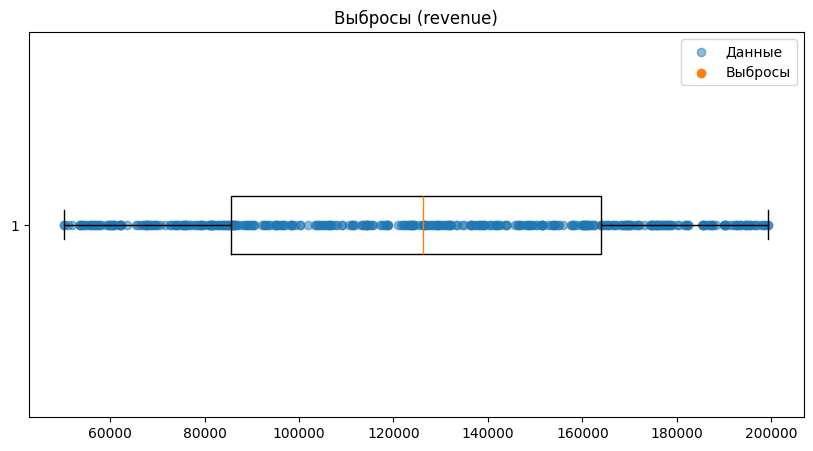

In [256]:
#"смотреть я буду на нaличие выбрасов методом межквартального размаха IQR и каждый столбец будувыводить отдельно"

#'revenue'
nach = dt['revenue'].quantile(0.25)
konc = dt['revenue'].quantile(0.75)

IQR = konc - nach
lower = nach - 1.5 * IQR
upper = konc + 1.5 * IQR

print(
    "'revenue'\n",
    "Q1", nach,"\n",
    "Q3", konc,"\n",
    "IQR", IQR,"\n",
    "Нижн возм гран", lower,"\n",
    "Верхн возм гран", upper,"\n"

    )

#"большая часть значений лежит между"
#"Q1 - 25%меньш"
#"Q3 - 75% больш"
#"IQR это где большая часть значений там нуту выбрасов по этой колонке"

out = dt[(dt['revenue']< lower)| (dt['revenue']>upper)]
print(
    "_"*50,"\n",
    " Самый маленькие)\n",
    dt.sort_values(by='revenue').head(5),"\n",
    "_"*50,"\n",
    "Самые большие)\n",
    dt.sort_values(by='revenue').tail(5),"\n",
    "_"*50,"\n",
    "Возможные выбросы:",len(out)
    )
# "Теперь тоже самое с остальными столбиками)"

nor = dt[(dt['revenue'] >= lower) & (dt['revenue'] <= upper)]

plt.figure(figsize=(10, 5))
plt.boxplot(dt['revenue'], vert=False)
plt.scatter(nor['revenue'], [1]*len(nor), alpha=0.5, label='Данные')
plt.scatter(out['revenue'], [1]*len(out), label='Выбросы')
plt.title(f'Выбросы (revenue)')
plt.legend()
plt.show()

'expenses'
 Q1 50785.75 
 Q3 116487.0 
 IQR 65701.25 
 Нижн возм гран -47766.125 
 Верхн возм гран 215038.875 

__________________________________________________ 
  Самый маленькие)
            date  revenue  expenses  customers  orders  profit
79   2023-03-21   114178     20163        173     139   94015
78   2023-03-20   190272     20671        127     294  169601
255  2023-09-13   174457     22461        343     137  151996
352  2023-12-19    84594     23081        309     166   61513
114  2023-04-25   138009     23191        405     235  114818 
 __________________________________________________ 
 Самые большие)
            date  revenue  expenses  customers  orders  profit
132  2023-05-13   168516    147734        237     279   20782
201  2023-07-21   164014    147896        470     146   16118
363  2023-12-30   180513    148392        178     222   32121
95   2023-04-06    62115    148563        247     105  -86448
289  2023-10-17   124069    149226         75      56  -25157 


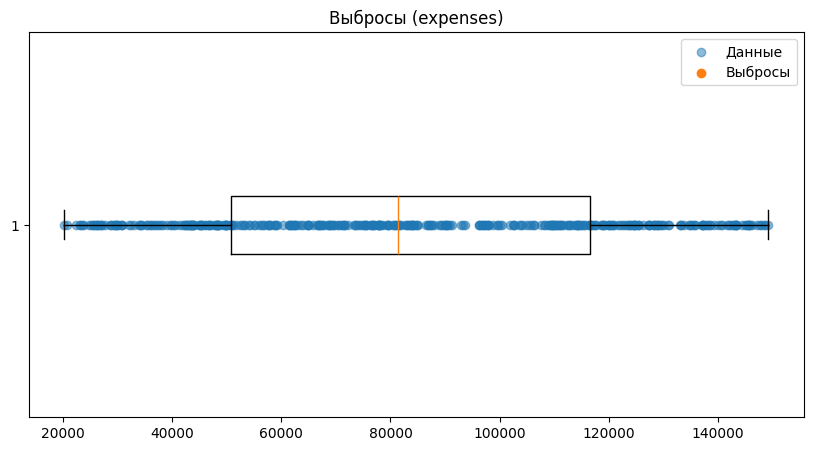

In [257]:
#'expenses'
nach = dt['expenses'].quantile(0.25)
konc = dt['expenses'].quantile(0.75)

IQR = konc - nach
lower = nach - 1.5 * IQR
upper = konc + 1.5 * IQR

print(
    "'expenses'\n",
    "Q1", nach,"\n",
    "Q3", konc,"\n",
    "IQR", IQR,"\n",
    "Нижн возм гран", lower,"\n",
    "Верхн возм гран", upper,"\n"

    )

out = dt[(dt['expenses']< lower)| (dt['expenses']>upper)]
nor = dt[(dt['expenses'] >= lower) & (dt['expenses'] <= upper)]

print(
    "_"*50,"\n",
    " Самый маленькие)\n",
    dt.sort_values(by='expenses').head(5),"\n",
    "_"*50,"\n",
    "Самые большие)\n",
    dt.sort_values(by='expenses').tail(5),"\n",
    "_"*50,"\n",
    "Возможные выбросы:",len(out)
    )

plt.figure(figsize=(10, 5))
plt.boxplot(dt['expenses'], vert=False)
plt.scatter(nor['expenses'], [1]*len(nor), alpha=0.5, label='Данные')
plt.scatter(out['expenses'], [1]*len(out), label='Выбросы')
plt.title(f'Выбросы (expenses)')
plt.legend()
plt.show()

'customers'
 Q1 155.75 
 Q3 398.25 
 IQR 242.5 
 Нижн возм гран -208.0 
 Верхн возм гран 762.0 

__________________________________________________ 
  Самый маленькие)
            date  revenue  expenses  customers  orders  profit
239  2023-08-28   130532     65838         51     126   64694
18   2023-01-19    92229     66851         52     292   25378
15   2023-01-16   193273     43291         53     298  149982
238  2023-08-27    67014     36905         54     296   30109
175  2023-06-25   192635    130990         56     211   61645 
 __________________________________________________ 
 Самые большие)
            date  revenue  expenses  customers  orders  profit
225  2023-08-14   169503    107527        491      21   61976
256  2023-09-14    81910     34291        493     119   47619
209  2023-07-29   169891    117661        494     162   52230
291  2023-10-19   175541     77941        496     143   97600
264  2023-09-22    81007     81332        497     167    -325 
 ______________

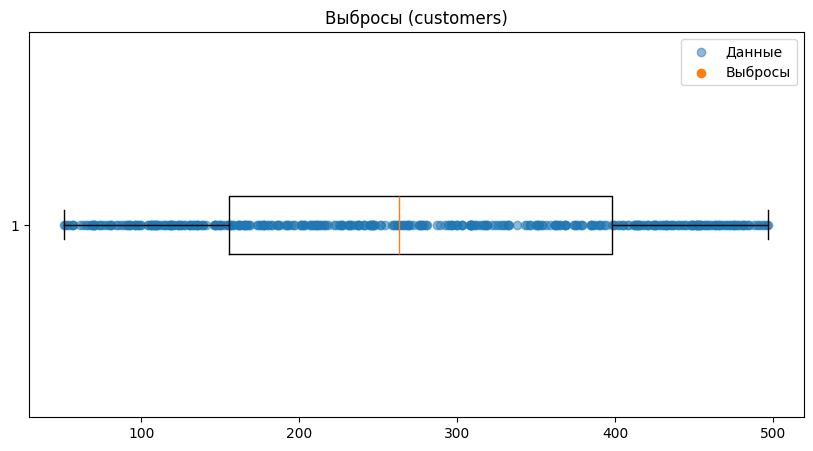

In [258]:
#'customers'
nach = dt['customers'].quantile(0.25)
konc = dt['customers'].quantile(0.75)

IQR = konc - nach
lower = nach - 1.5 * IQR
upper = konc + 1.5 * IQR

print(
    "'customers'\n",
    "Q1", nach,"\n",
    "Q3", konc,"\n",
    "IQR", IQR,"\n",
    "Нижн возм гран", lower,"\n",
    "Верхн возм гран", upper,"\n"

    )

out = dt[(dt['customers']< lower)| (dt['customers']>upper)]
nor = dt[(dt['customers'] >= lower) & (dt['customers'] <= upper)]

print(
    "_"*50,"\n",
    " Самый маленькие)\n",
    dt.sort_values(by='customers').head(5),"\n",
    "_"*50,"\n",
    "Самые большие)\n",
    dt.sort_values(by='customers').tail(5),"\n",
    "_"*50,"\n",
    "Возможные выбросы:",len(out)
    )

plt.figure(figsize=(10, 5))
plt.boxplot(dt['customers'], vert=False)
plt.scatter(nor['customers'], [1]*len(nor), alpha=0.5, label='Данные')
plt.scatter(out['customers'], [1]*len(out), label='Выбросы')
plt.title(f'Выбросы (customers)')
plt.legend()
plt.show()

'orders'
 Q1 94.0 
 Q3 229.0 
 IQR 135.0 
 Нижн возм гран -108.5 
 Верхн возм гран 431.5 

__________________________________________________ 
  Самый маленькие)
            date  revenue  expenses  customers  orders  profit
31   2023-02-01   185720    137990        452      20   47730
181  2023-07-01   109182     48138        252      20   61044
92   2023-04-03   118785     30749        399      21   88036
225  2023-08-14   169503    107527        491      21   61976
36   2023-02-06    95893     77022        354      23   18871 
 __________________________________________________ 
 Самые большие)
            date  revenue  expenses  customers  orders  profit
389  2024-01-25    85262    102617        182     296  -17355
303  2023-10-31    50207    139246        485     297  -89039
237  2023-08-26    67633     77866        390     298  -10233
15   2023-01-16   193273     43291         53     298  149982
315  2023-11-12    68752     23754         57     299   44998 
 ____________________

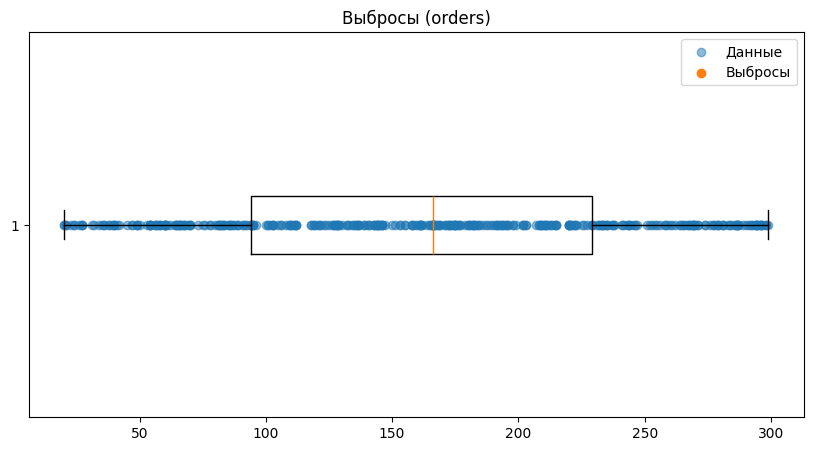

In [259]:
#'orders'
nach = dt['orders'].quantile(0.25)
konc = dt['orders'].quantile(0.75)

IQR = konc - nach
lower = nach - 1.5 * IQR
upper = konc + 1.5 * IQR

print(
    "'orders'\n",
    "Q1", nach,"\n",
    "Q3", konc,"\n",
    "IQR", IQR,"\n",
    "Нижн возм гран", lower,"\n",
    "Верхн возм гран", upper,"\n"

    )

out = dt[(dt['orders']< lower)| (dt['orders']>upper)]
nor = dt[(dt['orders'] >= lower) & (dt['orders'] <= upper)]

print(
    "_"*50,"\n",
    " Самый маленькие)\n",
    dt.sort_values(by='orders').head(5),"\n",
    "_"*50,"\n",
    "Самые большие)\n",
    dt.sort_values(by='orders').tail(5),"\n",
    "_"*50,"\n",
    "Возможные выбросы:",len(out)
    )


plt.figure(figsize=(10, 5))
plt.boxplot(dt['orders'], vert=False)
plt.scatter(nor['orders'], [1]*len(nor), alpha=0.5, label='Данные')
plt.scatter(out['orders'], [1]*len(out), label='Выбросы')
plt.title(f'Выбросы (orders)')
plt.legend()
plt.show()

'profit'
 Q1 6535.5 
 Q3 80278.5 
 IQR 73743.0 
 Нижн возм гран -104079.0 
 Верхн возм гран 190893.0 

__________________________________________________ 
  Самый маленькие)
            date  revenue  expenses  customers  orders  profit
303  2023-10-31    50207    139246        485     297  -89039
95   2023-04-06    62115    148563        247     105  -86448
130  2023-05-11    55704    142139        365     151  -86435
205  2023-07-25    68743    145873        394     103  -77130
199  2023-07-19    62289    138527        136     165  -76238 
 __________________________________________________ 
 Самые большие)
            date  revenue  expenses  customers  orders  profit
255  2023-09-13   174457     22461        343     137  151996
56   2023-02-26   187348     26548        162     119  160800
218  2023-08-07   190507     26910        338     220  163597
329  2023-11-26   197235     29496         91      27  167739
78   2023-03-20   190272     20671        127     294  169601 
 ________

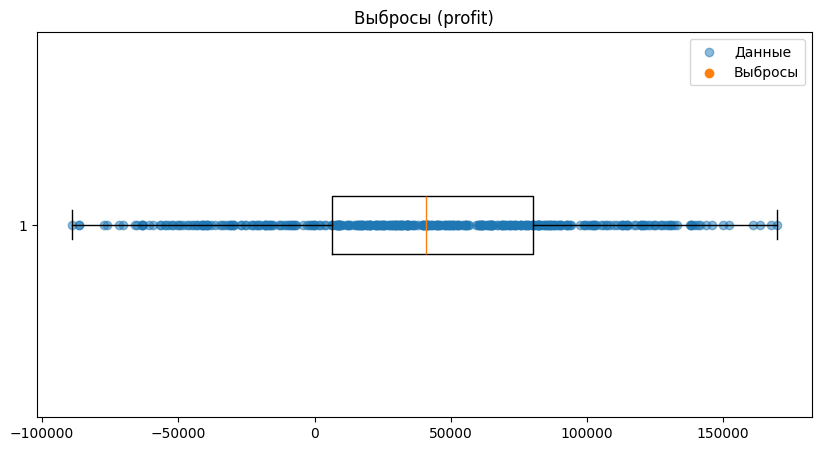

In [260]:
#'profit'
nach = dt['profit'].quantile(0.25)
konc = dt['profit'].quantile(0.75)

IQR = konc - nach
lower = nach - 1.5 * IQR
upper = konc + 1.5 * IQR

print(
    "'profit'\n",
    "Q1", nach,"\n",
    "Q3", konc,"\n",
    "IQR", IQR,"\n",
    "Нижн возм гран", lower,"\n",
    "Верхн возм гран", upper,"\n"

    )

out = dt[(dt['profit']< lower)| (dt['profit']>upper)]
print(
    "_"*50,"\n",
    " Самый маленькие)\n",
    dt.sort_values(by='profit').head(5),"\n",
    "_"*50,"\n",
    "Самые большие)\n",
    dt.sort_values(by='profit').tail(5),"\n",
    "_"*50,"\n",
    "Возможные выбросы:",len(out)
    )

# "Похоже что выбрасов нету это странно или я чето не так делаю или это очень хорошик данные"

nor = dt[(dt['profit'] >= lower) & (dt['profit'] <= upper)]

plt.figure(figsize=(10, 5))
plt.boxplot(dt['profit'], vert=False)
plt.scatter(nor['profit'], [1]*len(nor), alpha=0.5, label='Данные')
plt.scatter(out['profit'], [1]*len(out), label='Выбросы')
plt.title(f'Выбросы (profit)')
plt.legend()
plt.show()

In [261]:
# переобразовать даты в дататайм
# "1) надо также проверить нет ли ошибок в даныз например profit это revenue - expenses"
# "2) также надо почекать выручку если она отрицательная значит появился варишка или это какаято лютая ошибка на какомто из этапов"
# "3) по расходам вопрос знатьбы это расходы на материалы или расходы на все и нат технику оборудование и таму подобное если сугубо на материалы то выручка обязана привышать расходы"
# "4) количество клиентов и закащов не должно быть отрицательным"
# "5) также проверить прибыль и выручка  прибыль не должна быть выше выручки"
# "6) также по датам отсортировать и поискать чтото типо пропусков или чегото сранного"

In [ ]:
dt["date"] = pd.to_datetime(dt["date"])

In [263]:
#"1"
dt['check'] = dt['revenue'] - dt['expenses']
wrong_profit = dt[dt['profit'] != dt['check']]

print("Ошибок (profit)", len(wrong_profit))

Ошибок (profit) 0


In [264]:
#"2"
otr_vr = dt[dt['revenue'] < 0]
print("Выручк в -:", len(otr_vr))

Выручк в -: 0


In [265]:
#"3"
high = dt[dt['expenses'] > dt['revenue']]
print(
    "Расх выше выр:",len(high),"\n",
    high.head(),"\n"
    )

#"похоже что и првда тут и считается оборудование"

Расх выше выр: 93 
          date  revenue  expenses  customers  orders  profit  check
8  2023-01-09    54703     70331        237     237  -15628 -15628
13 2023-01-14    76017    117359        168      60  -41342 -41342
17 2023-01-18    67778    117539         63     169  -49761 -49761
27 2023-01-28    83142    127315         73      66  -44173 -44173
28 2023-01-29    76916    118723        211     220  -41807 -41807 



In [266]:
#"4"
ncus = dt[dt['customers'] < 0]
nord = dt[dt['orders'] < 0]

print(
    " Отриц клиенты:", len(ncus),"\n",
    "Отриц заказы:", len(nord)
    )

 Отриц клиенты: 0 
 Отриц заказы: 0


In [267]:
#"5"
wr = dt[dt['profit'] > dt['revenue']]
print(
    "Приб > Выр:", len(wr)
    )

Приб > Выр: 0


In [268]:
#"6"
dt['date'] = pd.to_datetime(dt['date'], errors='coerce')
wrong_dates = dt[dt['date'].isnull()]
print("Проблемы с датами:", len(wrong_dates))

dt_sorted = dt.sort_values(by='date')
dt_sorted['date_diff'] = dt_sorted['date'].diff()
gaps = dt_sorted[dt_sorted['date_diff'] > pd.Timedelta(days=1)]
print("Пропуски в датах:", len(gaps))

Проблемы с датами: 0
Пропуски в датах: 0


### Расчет показателей ,анализ и визуализация

In [277]:
#"Сумарные показатели"
summa = dt[["revenue", "expenses", "profit", "customers", "orders"]].sum()
print("Суммарные показатели")
for col, val in summa.items():
    print(f"{col}: {val:,}".replace(",", " "))

Суммарные показатели
revenue: 49 918 197
expenses: 33 697 398
profit: 16 220 799
customers: 108 925
orders: 65 123


In [281]:
sred = dt[["revenue", "expenses", "profit", "customers", "orders"]].mean()
print("Средние показатели")
for col, val in sred.items():
    print(f"{col}: {val:,}".replace(",", " "))

Средние показатели
revenue: 124 795.4925
expenses: 84 243.495
profit: 40 551.9975
customers: 272.3125
orders: 162.8075


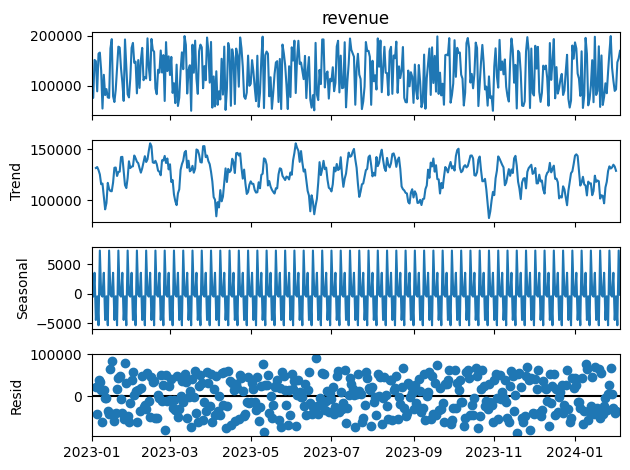

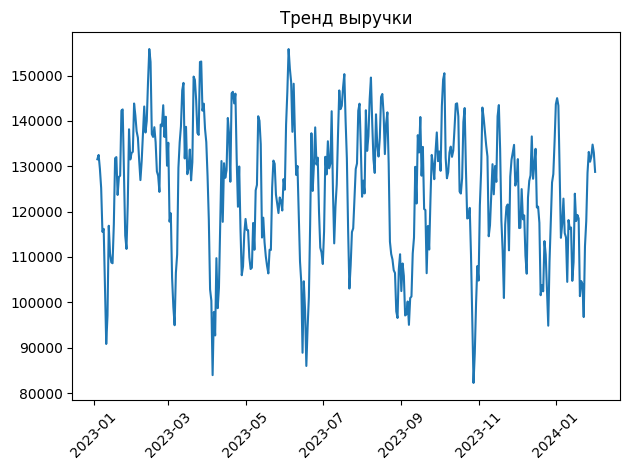

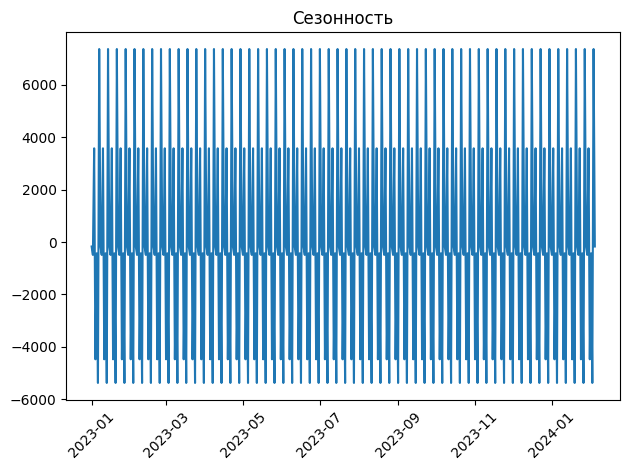

In [ ]:
df = dt.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df = df.set_index("date")

series = df["revenue"]
series = series.asfreq("D")
series = series.ffill()

result = seasonal_decompose(series, period=7)
result.plot()

plt.tight_layout()
plt.show()

plt.figure()
plt.plot(result.trend)
plt.title("Тренд выручки")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(result.seasonal)
plt.title("Сезонность")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#"есть сезонность тренд +- ставильный нет какого то силного роста или падения"

In [297]:
total_revenue = df["revenue"].sum()

df["revenue_share"] = df["revenue"] / total_revenue * 100
df[["revenue", "revenue_share"]].head()

,revenue,revenue_share
date,,
2023-01-01,124131,0.248669
2023-01-02,75963,0.152175
2023-01-03,151757,0.304011
2023-01-04,149259,0.299007
2023-01-05,89063,0.178418


day
Friday       13.690853
Monday       14.068447
Saturday     15.122912
Sunday       14.540060
Thursday     14.190543
Tuesday      14.671323
Wednesday    13.715862
Name: revenue, dtype: float64


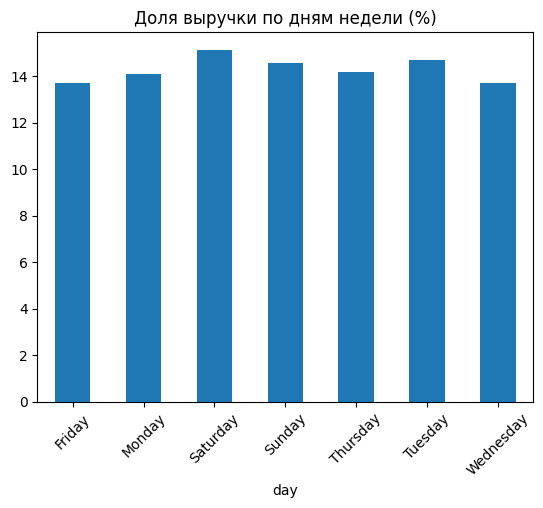

In [299]:
df["day"] = df.index.day_name()

day_share = df.groupby("day")["revenue"].sum()

day_share = day_share / day_share.sum() * 100

print(day_share)
day_share.plot(kind="bar")
plt.title("Доля выручки по дням недели (%)")
plt.xticks(rotation=45)
plt.show()

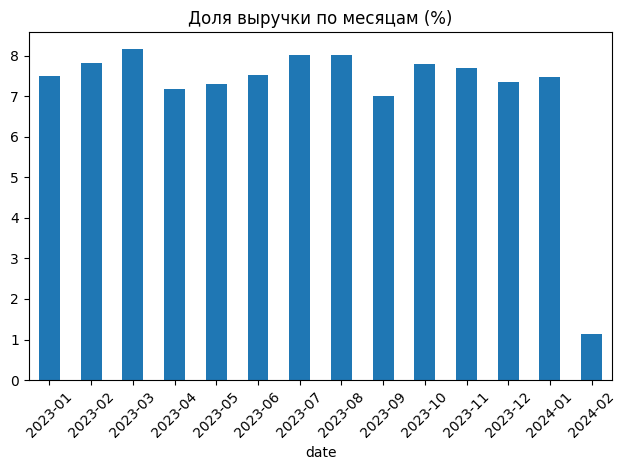

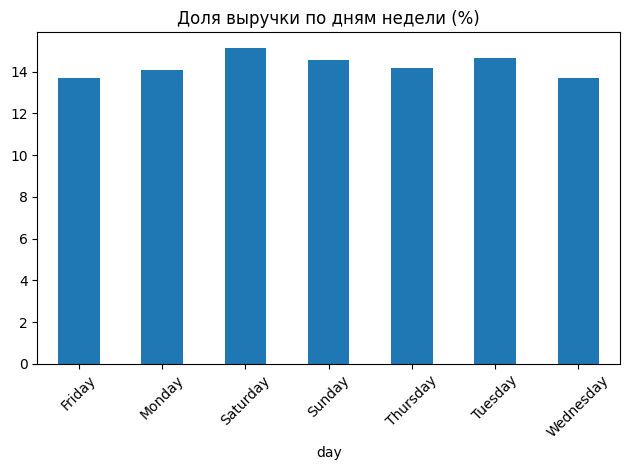

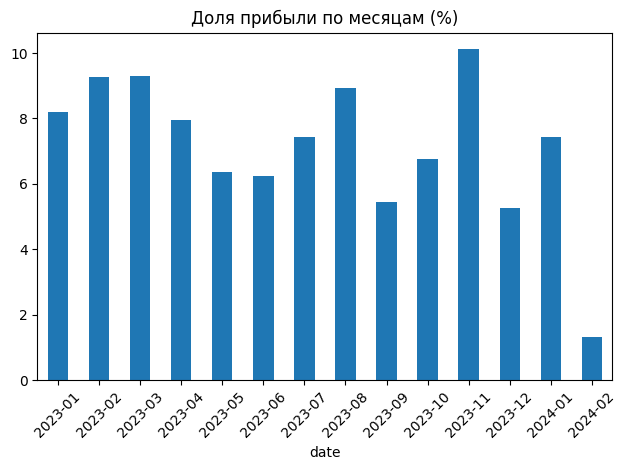

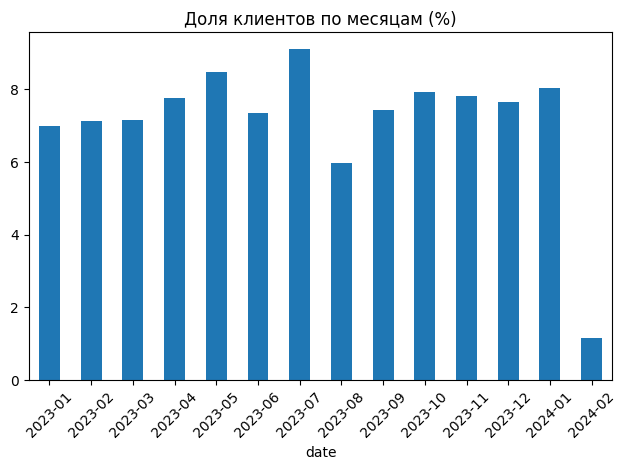

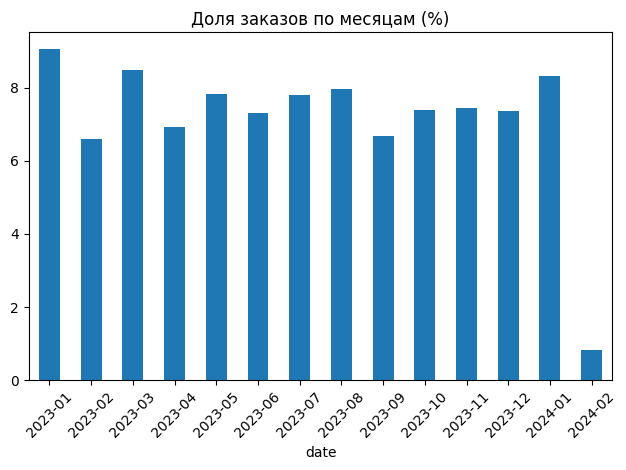

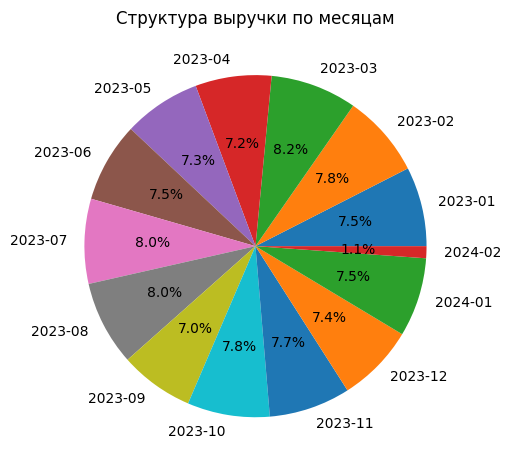

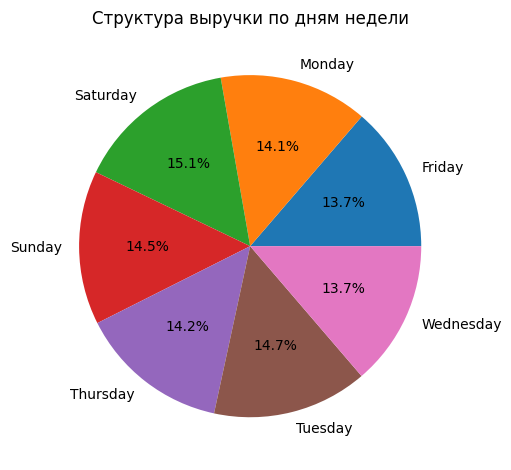

In [307]:
import pandas as pd
import matplotlib.pyplot as plt


df = dt.copy()
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df = df.set_index("date")

monthly = df.groupby(df.index.to_period("M"))["revenue"].sum()
monthly_share = monthly / monthly.sum() * 100
plt.figure()
monthly_share.plot(kind="bar")
plt.title("Доля выручки по месяцам (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

df["day"] = df.index.day_name()
day_share = df.groupby("day")["revenue"].sum()
day_share = day_share / day_share.sum() * 100
plt.figure()
day_share.plot(kind="bar")
plt.title("Доля выручки по дням недели (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


monthly_profit = df.groupby(df.index.to_period("M"))["profit"].sum()
monthly_profit_share = monthly_profit / monthly_profit.sum() * 100
plt.figure()
monthly_profit_share.plot(kind="bar")
plt.title("Доля прибыли по месяцам (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_customers = df.groupby(df.index.to_period("M"))["customers"].sum()
monthly_customers_share = monthly_customers / monthly_customers.sum() * 100
plt.figure()
monthly_customers_share.plot(kind="bar")
plt.title("Доля клиентов по месяцам (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_orders = df.groupby(df.index.to_period("M"))["orders"].sum()
monthly_orders_share = monthly_orders / monthly_orders.sum() * 100
plt.figure()
monthly_orders_share.plot(kind="bar")
plt.title("Доля заказов по месяцам (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure()
monthly_share.plot(kind="pie", autopct="%1.1f%%")
plt.title("Структура выручки по месяцам")
plt.ylabel("")
plt.tight_layout()
plt.show()

plt.figure()
day_share.plot(kind="pie", autopct="%1.1f%%")
plt.title("Структура выручки по дням недели")
plt.ylabel("")
plt.tight_layout()
plt.show()

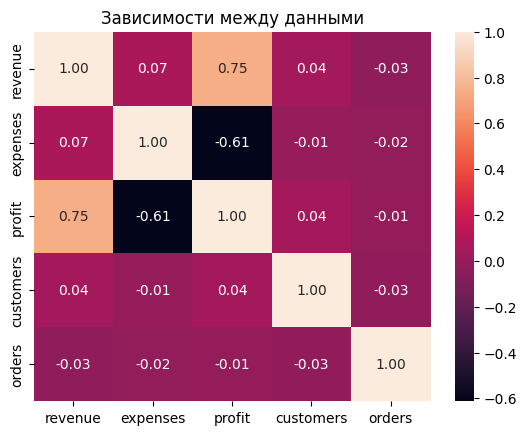

In [310]:
#"зависимости есть но самая большая зависимость revenue - profit остальные не сильно влияют друг на друга"
corr = df[["revenue", "expenses", "profit", "customers", "orders"]].corr()

plt.figure()
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Зависимости между данными")
plt.show()